# 1. Charger les images avec image_dataset_from_directory. 

In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt

# base_path = '/kaggle/input/datasets/princelv84/dogsvscats'  base_path + '/train', base_path + '/test'

# Chargement
train_ds = tf.keras.utils.image_dataset_from_directory(
    'Data/train',
    image_size = (224, 224),
    batch_size = 32,
    seed       = 42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    'Data/test',
    image_size = (224, 224),
    batch_size = 32,
    seed       = 42
)

class_names = train_ds.class_names
print(class_names)


Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
['cats', 'dogs']


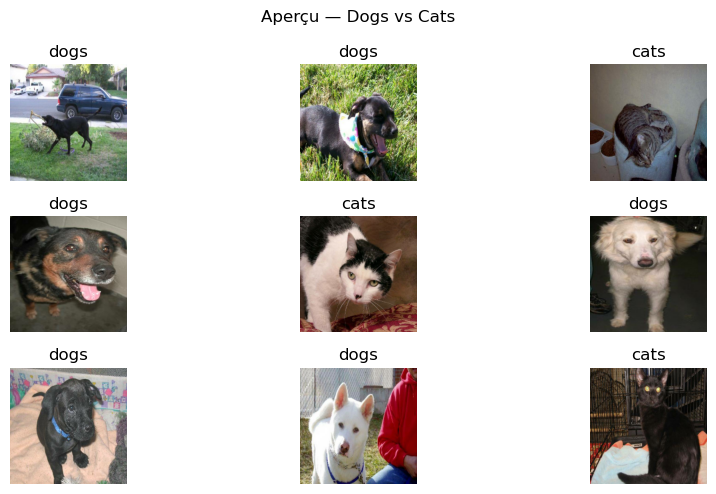

In [21]:
# Aperçu du data set
class_names = train_ds.class_names

for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 5))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i].numpy()])
        plt.axis("off")
    plt.suptitle("Aperçu — Dogs vs Cats")
    plt.tight_layout()
    plt.show()

# 2-Creation du CNN

In [22]:
from tensorflow.keras.models import Sequential # importation de larchitectur qui permet que les couches s'empiles les unes sur les autres
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Rescaling, Dropout # importtion des differrente couches du CNN


model= Sequential([
    Rescaling(1./255,
              input_shape=(224,224,3)), #permet de ramener les pixels entre 0 et 1
    Conv2D(32, (3,3), activation='relu'), #premier convolution avec 32 filtres
    MaxPooling2D((2,2)), #premier pooling
    Conv2D(64, (3,3), activation='relu'), #deuxieme couche de convolution avec 64 filtres
    MaxPooling2D((2,2)), #deuxieme pooling
    Conv2D(128, (3,3), activation='relu'), # troisime couche de convoltion avec 124 filtres
    MaxPooling2D((2,2)),
    Flatten(), #permet de convertir la matrice en vecteur
    Dense(128, activation='relu'), # 128 neurones combines les caracterisques extrait par les conv
    Dropout(0.5),# couche qui ddesactive 50% des neuronnes pendant lentrainement a chaque iteration
    Dense(1, activation= 'sigmoid')# couche de sorti avec une activation sigmoide car nous sommes dans une classifiction binaire
    
])

# Compilation du modele

In [4]:
model.compile(
    optimizer='adam', # choisit l;algorithme qui mettra a jour les poids du reseaux
    loss='binary_crossentropy', # mesure l'erreur entre les predeictions du  odeles et les vraies etiquettes pour deux classe
    metrics= ['accuracy'] #demandes a tensorflow dafficher le pourcentages de predictions correctes
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35
)

loss_train, acc_train = model.evaluate(train_ds)
loss_val, acc_val = model.evaluate(val_ds)

print(f"Train Accuracy : {acc_train*100:.2f}%")
print(f"Validation Accuracy : {acc_val*100:.2f}%")

Epoch 1/35
500/500 ━━━━━━━━━━━━━━━━━━━━ 367s 727ms/step - accuracy: 0.5824 - loss: 0.6839 - val_accuracy: 0.6460 - val_loss: 0.6518
Epoch 2/35
157/500 ━━━━━━━━━━━━━━━━━━━━ 3:52 679ms/step - accuracy: 0.6584 - loss: 0.6322

KeyboardInterrupt: 

# 3. Sauvegarder le modèle et tester la prédiction sur une photo personnelle.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
Score brut : 0.0000
C'est un CHAT


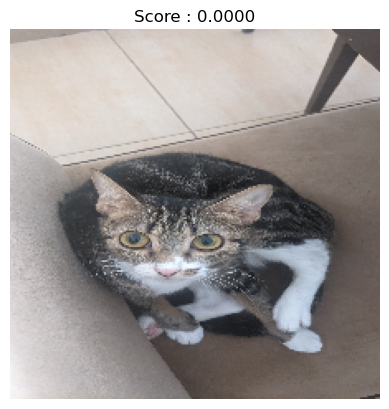

In [33]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

model = tf.keras.models.load_model('modele_dogs_cats.keras')

img_path = 'photo test/PXL_20260701_155938451.jpg'  #Chemin de la photo
img = image.load_img(img_path, target_size=(224, 224)) 

img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
print(f"Score brut : {prediction[0][0]:.4f}")

if prediction[0][0] > 0.5:
    print("C'est un CHIEN")
else:
    print("C'est un CHAT")

plt.imshow(img)
plt.axis('off')
plt.title(f"Score : {prediction[0][0]:.4f}")
plt.show()


In [24]:
print(model.input_shape)

(None, 224, 224, 3)
